# Vision Transformer с нуля на PyTorch

В этой работе нужно реализовать основные части Vision Transformer (ViT): разбиение изображения на патчи, patch embedding, positional embeddings, multi-head self-attention, transformer encoder block и итоговую модель классификации.

**Цель:** понять, как изображение превращается в последовательность токенов и как Transformer применяют к задаче классификации изображений.

## Правила

- Нельзя использовать готовую реализацию ViT из `timm`, `torchvision.models`, HuggingFace и подобных библиотек.
- Можно использовать PyTorch, torchvision datasets/transforms, matplotlib, numpy.
- В основных заданиях attention нужно реализовать вручную.


# 0. Установка и импорты

Если вы работаете в Google Colab, обычно достаточно установить только `torchvision`, если он не установлен.


In [49]:
import math
import random
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

try:
    import torchvision
    import torchvision.transforms as T
except Exception as e:
    torchvision = None
    T = None
    print("torchvision is not available:", e)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cpu


# 1. Идея ViT

Обычная CNN обрабатывает изображение локальными свёртками. Vision Transformer делает иначе:

1. Делит изображение на маленькие квадратные патчи.
2. Каждый патч превращает в вектор — токен.
3. Добавляет positional embedding, чтобы модель знала порядок патчей.
4. Пропускает последовательность токенов через Transformer Encoder.
5. Использует специальный `[CLS]` токен для классификации.

Для изображения размера `H x W` и patch size `P` количество патчей:

$$N = 
{H}/{P} \cdot
{W}/{P}$$

Если изображение CIFAR10 имеет размер `32 x 32`, а patch size равен `4`, то получится `8 x 8 = 64` патча.

# Теоретический вопрос 1 

1. Зачем нужен токен CLS?
2. В чем идея деления пространства признаков на "головы внимания"?
3. На чем основывается выбор размера патча? 

## Ваш ответ: 
1) Чтобы после обработки всех патчей использовать его выход как итоговое представление всего изображения для классификации.
2) Чтобы модель не зацикливалась на одном типе связи, а обрабатывала разные возможные связи.
3) Для высокой детализации, обнаружения мелких связей патч должен быть меньше (но глобальные связи видны хуже и патчей очень много). Для обнаружения глобальных связей патчи должны быть крупнее (но будут хуже обнаруживаться мелкие связи). В зависимости от задачи ищут подходящий баланс.


# 2. Разбиение изображения на патчи

Реализуйте функцию `image_to_patches`.

In [50]:
def image_to_patches(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """
    Convert batch of images into a batch of flattened patches.

    Args:
        x: Tensor of shape [B, C, H, W]
        patch_size: int, patch size P

    Returns:
        patches: Tensor of shape [B, N, C * P * P]
    """
    ############################################################################
    # TODO: Реализуйте разбиение изображения на патчи #
    # TODO: проверьте, что H и W делятся на patch_size
    # TODO: используйте unfold или reshape/permute
    ############################################################################
    # raise NotImplementedError("Implement image_to_patches")
    B, C, H, W = x.shape
    if H % patch_size != 0 or W % patch_size != 0:
        raise ValueError(f"H={H}, W={W}, patch_size={patch_size} -> sizes must be divisible")
    patches = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.permute(0, 2, 3, 1, 4, 5)
    patches = patches.reshape(B, -1, C * patch_size * patch_size)
    return patches
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
    

In [51]:
# Тесты для image_to_patches
x_test = torch.arange(2 * 3 * 8 * 8).float().reshape(2, 3, 8, 8)
patches = image_to_patches(x_test, patch_size=4)
assert patches.shape == (2, 4, 3 * 4 * 4), patches.shape
manual_first_patch = x_test[0, :, 0:4, 0:4].reshape(-1)
assert torch.equal(patches[0, 0], manual_first_patch)
print("image_to_patches tests passed")


image_to_patches tests passed


# 3. Patch Embedding

Далее патчи преобразуем в эмбеддинги длиной embed_dim в `PatchEmbedding`:

`[B, C, H, W] -> [B, N, embed_dim]`


In [52]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size
        ############################################################################
        # TODO: создайте Linear слой для проекции patch_dim -> embed_dim
        ############################################################################
        self.proj = nn.Linear(self.patch_dim, embed_dim)
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: получите patches через image_to_patches
        # TODO: примените self.proj
        ############################################################################
        patches = image_to_patches(x, self.patch_size)  
        tokens = self.proj(patches)
        return tokens
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

In [53]:
# Тесты для PatchEmbedding
patch_embed = PatchEmbedding(image_size=32, patch_size=4, in_channels=3, embed_dim=64)
x = torch.randn(5, 3, 32, 32)
out = patch_embed(x)
assert out.shape == (5, 64, 64), out.shape
assert patch_embed.num_patches == 64
print("PatchEmbedding tests passed")


PatchEmbedding tests passed


# 4. Positional Embeddings и CLS token

Transformer сам по себе не знает порядок токенов. Поэтому к токенам добавляют positional embeddings.

Для классификации часто добавляют специальный `[CLS]` токен. После Transformer Encoder берут именно его выход и подают в классификатор.

Реализуйте класс `TokenPreparation`:

```python
patch_tokens: [B, N, D]
output:       [B, N + 1, D]
```


In [54]:
class TokenPreparation(nn.Module):
    def __init__(self, num_patches: int, embed_dim: int):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        ############################################################################
        # TODO: создайте learnable cls_token формы [1, 1, D]
        # TODO: создайте learnable pos_embed формы [1, N + 1, D]
        ############################################################################
        self.cls_token = torch.nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = torch.nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: расширьте cls_token под batch size
        # TODO: соедините cls_token и patch_tokens по dimension=1
        # TODO: добавьте positional embedding
        ############################################################################
        B = patch_tokens.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, D]
        x = torch.cat([cls_tokens, patch_tokens], dim=1)  # [B, N+1, D]
        x = x + self.pos_embed  # broadcasting по batch
        return x
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################


In [55]:
# Тесты для TokenPreparation
prep = TokenPreparation(num_patches=64, embed_dim=128)
tokens = torch.randn(2, 64, 128)
out = prep(tokens)
assert out.shape == (2, 65, 128), out.shape
assert isinstance(prep.cls_token, nn.Parameter)
assert isinstance(prep.pos_embed, nn.Parameter)
print("TokenPreparation tests passed")


TokenPreparation tests passed


# 5. Scaled Dot-Product Attention

Реализуйте attention:

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

Вход: `q, k, v: [B, heads, N, head_dim]`

Выход:

- `out: [B, heads, N, head_dim]`
- `attn: [B, heads, N, N]`


In [56]:
def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    dropout: Optional[nn.Module] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    ############################################################################
    # TODO: scores = q @ k.transpose(-2, -1)
    # TODO: scores / sqrt(head_dim)
    # TODO: softmax по последней размерности
    # TODO: dropout, если задан
    # TODO: out = attn @ v
    ############################################################################
    scores = q @ k.transpose(-2, -1)
    scores = scores / math.sqrt(q.shape[-1])
    attn = F.softmax(scores, dim=-1)
    if dropout is not None:
        attn = dropout(attn)
    out = attn @ v
    return out, attn
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
        

In [57]:
# Тесты для scaled_dot_product_attention
q = torch.randn(2, 4, 10, 16)
k = torch.randn(2, 4, 10, 16)
v = torch.randn(2, 4, 10, 16)
out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (2, 4, 10, 16)
assert attn.shape == (2, 4, 10, 10)
assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1)), atol=1e-5)
print("scaled_dot_product_attention tests passed")


scaled_dot_product_attention tests passed


# 6. Multi-Head Self-Attention

Реализуйте `MultiHeadSelfAttention`.

Внутри нужно:

1. Получить `qkv` одной линейной проекцией или тремя отдельными.
2. Разделить embedding dimension на `num_heads` голов.
3. Применить scaled dot-product attention.
4. Склеить головы обратно.
5. Применить финальную линейную проекцию.


In [58]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, attn_dropout: float = 0.0, proj_dropout: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        ############################################################################
        # TODO: создайте qkv projection: D -> 3D
        # TODO: создайте output projection: D -> D
        ############################################################################
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj_drop = nn.Dropout(proj_dropout)
        self.last_attention: Optional[torch.Tensor] = None
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: qkv = self.qkv(x)
        # TODO: reshape/permute к [B, heads, N, head_dim]
        # TODO: вызовите scaled_dot_product_attention
        # TODO: сохраните attention weights в self.last_attention
        # TODO: склейте головы и примените финальную проекцию
        ############################################################################
        B, N, D = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        out, attn = scaled_dot_product_attention(q, k, v, self.attn_drop)
        self.last_attention = attn
        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

In [59]:
# Тесты для MultiHeadSelfAttention
mha = MultiHeadSelfAttention(embed_dim=128, num_heads=8)
x = torch.randn(3, 65, 128)
y = mha(x)
assert y.shape == x.shape
assert mha.last_attention is not None
assert mha.last_attention.shape == (3, 8, 65, 65)
print("MultiHeadSelfAttention tests passed")


MultiHeadSelfAttention tests passed


# 7. MLP block

В Transformer Encoder после attention идёт feed-forward network:

`Linear(D, hidden_dim) -> GELU -> Dropout -> Linear(hidden_dim, D) -> Dropout`


In [60]:
class MLP(nn.Module):
    def __init__(self, embed_dim: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        ############################################################################
        # TODO: реализуйте MLP через nn.Sequential
        ############################################################################
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO ???
        return self.net(x)


In [61]:
# Тесты для MLP
mlp = MLP(embed_dim=128, mlp_ratio=4.0, dropout=0.1)
x = torch.randn(2, 65, 128)
y = mlp(x)
assert y.shape == x.shape
print("MLP tests passed")


MLP tests passed


# 8. Transformer Encoder Block

Реализуйте Pre-LN блок:

```text
x = x + Attention(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```


In [62]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, attn_dropout: float = 0.0):
        super().__init__()
        ############################################################################
        ## TODO: создайте norm1, attn, norm2, mlp
        ############################################################################
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout,
            proj_dropout=dropout
        )
        self.mlp = MLP(
            embed_dim=embed_dim,
            mlp_ratio=mlp_ratio,
            dropout=dropout
        )
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: residual connection around attention
        # TODO: residual connection around MLP
        ############################################################################
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        


In [63]:
# Тесты для TransformerEncoderBlock
block = TransformerEncoderBlock(embed_dim=128, num_heads=8, dropout=0.1, attn_dropout=0.1)
x = torch.randn(2, 65, 128)
y = block(x)
assert y.shape == x.shape
print("TransformerEncoderBlock tests passed")


TransformerEncoderBlock tests passed


# 9. Полная модель Vision Transformer

Соберите полный ViT:

1. PatchEmbedding
2. TokenPreparation
3. Несколько TransformerEncoderBlock
4. LayerNorm
5. Classification head


In [64]:
@dataclass
class ViTConfig:
    image_size: int = 32
    patch_size: int = 4
    in_channels: int = 3
    num_classes: int = 10
    embed_dim: int = 128
    depth: int = 4
    num_heads: int = 8
    mlp_ratio: float = 4.0
    dropout: float = 0.1
    attn_dropout: float = 0.1


class VisionTransformer(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config
        ############################################################################
        # TODO: создайте PatchEmbedding
        # TODO: создайте TokenPreparation
        # TODO: создайте список TransformerEncoderBlock
        # TODO: создайте norm и head
        ############################################################################
        self.patch_embed = PatchEmbedding(
            image_size=config.image_size,
            patch_size=config.patch_size,
            in_channels=config.in_channels,
            embed_dim=config.embed_dim
        )
        num_patches = self.patch_embed.num_patches
        self.token_prep = TokenPreparation(
            num_patches=num_patches,
            embed_dim=config.embed_dim
        )
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=config.embed_dim,
                num_heads=config.num_heads,
                mlp_ratio=config.mlp_ratio,
                dropout=config.dropout,
                attn_dropout=config.attn_dropout
            )
            for _ in range(config.depth)
        ])
        self.norm = nn.LayerNorm(config.embed_dim)
        self.head = nn.Linear(config.embed_dim, config.num_classes)
        self.apply(self._init_weights)
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    # def forward_features(self, x: torch.Tensor) -> torch.Tensor:
    #     x = self.patch_embed(x)
    #     x = self.token_prep(x)
    #     x = self.dropout(x)
    #     for block in self.blocks:
    #         x = block(x)
    #     x = self.norm(x)
    #     cls_token = x[:, 0]
    #     return cls_token

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: patch embedding
        # TODO: add cls token and pos embeddings
        # TODO: transformer blocks
        # TODO: final norm
        # TODO: take cls token
        # TODO: classification head
        ############################################################################
        x = self.patch_embed(x)
        x = self.token_prep(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token = x[:, 0]  # [B, D]
        logits = self.head(cls_token)
        return logits
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################


In [65]:
# Тесты для VisionTransformer
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=2, num_heads=8, num_classes=10)
model = VisionTransformer(config)
x = torch.randn(4, 3, 32, 32)
logits = model(x)
assert logits.shape == (4, 10), logits.shape
print("VisionTransformer tests passed")


VisionTransformer tests passed

# 10. Данные CIFAR10

In [66]:
def get_cifar10_loaders(batch_size: int = 128, val_size: int = 5000):
    assert torchvision is not None, "torchvision is required for CIFAR10"
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
    test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
    train_size = len(full_train) - val_size
    train_set, val_set = random_split(full_train, [train_size, val_size])
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


# 11. Training loop

Реализуйте функции `train_one_epoch` и `evaluate`.

Требования:

- использовать `model.train()` при обучении;
- использовать `model.eval()` при оценке;
- считать средний loss;
- считать accuracy.


In [67]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device: str) -> Dict[str, float]:
    # TODO: training loop
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size
    return {
        "loss": total_loss / total_count,
        "acc": total_correct / total_count
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device: str) -> Dict[str, float]:
    # TODO: evaluation loop
    # 
    # return {"loss": total_loss / total_count, "acc": total_correct / total_count}
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "acc": total_correct / total_count
    }


In [68]:
# Быстрая проверка training loop на случайных данных
class RandomImageDataset(torch.utils.data.Dataset):
    def __init__(self, n=128, num_classes=10):
        self.x = torch.randn(n, 3, 32, 32)
        self.y = torch.randint(0, num_classes, (n,))
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

random_loader = DataLoader(RandomImageDataset(n=64), batch_size=16, shuffle=True)
model = VisionTransformer(ViTConfig(depth=1, embed_dim=64, num_heads=4)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
train_metrics = train_one_epoch(model, random_loader, optimizer, criterion, DEVICE)
val_metrics = evaluate(model, random_loader, criterion, DEVICE)
assert "loss" in train_metrics and "acc" in train_metrics
assert "loss" in val_metrics and "acc" in val_metrics
print("training loop tests passed", train_metrics, val_metrics)


training loop tests passed {'loss': 2.3525224924087524, 'acc': 0.0625} {'loss': 2.1966625452041626, 'acc': 0.1875}


# 12. Запуск обучения

Рекомендуемые параметры для первого запуска:

```python
ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
```

Для быстрой проверки можно поставить `depth=2`, `embed_dim=64`, `num_heads=4`.

### Validation acc > 0.6 => 100% score


In [69]:
# Раскомментируйте для обучения на CIFAR10

train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=128)
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
model = VisionTransformer(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
epochs = 10
for epoch in range(1, epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    print(f"Epoch {epoch:02d}: train loss={train_metrics['loss']:.4f}, train acc={train_metrics['acc']:.4f}, val loss={val_metrics['loss']:.4f}, val acc={val_metrics['acc']:.4f}")


Files already downloaded and verified
Files already downloaded and verified
Epoch 01: train loss=1.8616, train acc=0.3031, val loss=1.7137, val acc=0.3672
Epoch 02: train loss=1.5899, train acc=0.4141, val loss=1.4963, val acc=0.4498
Epoch 03: train loss=1.4370, train acc=0.4772, val loss=1.3703, val acc=0.5082
Epoch 04: train loss=1.3561, train acc=0.5099, val loss=1.3172, val acc=0.5224
Epoch 05: train loss=1.2948, train acc=0.5344, val loss=1.2474, val acc=0.5474
Epoch 06: train loss=1.2303, train acc=0.5595, val loss=1.2088, val acc=0.5606
Epoch 07: train loss=1.1782, train acc=0.5772, val loss=1.1649, val acc=0.5824
Epoch 08: train loss=1.1348, train acc=0.5917, val loss=1.1140, val acc=0.5986
Epoch 09: train loss=1.0976, train acc=0.6059, val loss=1.0547, val acc=0.6232
Epoch 10: train loss=1.0609, train acc=0.6217, val loss=1.0279, val acc=0.6302


# 13. Графики обучения

Постройте графики loss и accuracy.


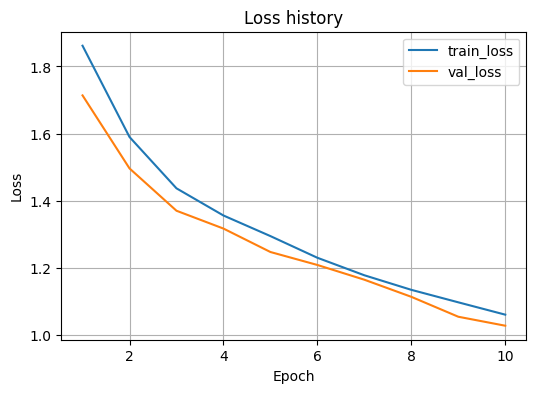

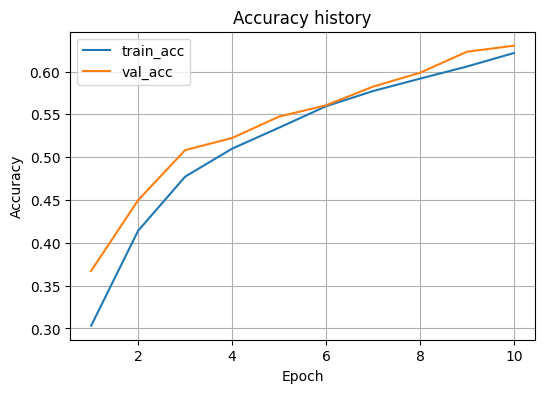

In [70]:
def plot_history(history: Dict[str, List[float]]):
    if not history.get("train_loss"):
        print("History is empty. Train the model first or pass a filled history dictionary.")
        return

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss history")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy history")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)


# 14. Дополнительное задание: визуализация attention

После forward pass в каждом attention-блоке сохранено поле `last_attention`.

Форма: `[B, heads, N + 1, N + 1]`

Для визуализации можно взять attention из CLS token к patch tokens:

```python
attn[0, head_id, 0, 1:]
```

Затем reshape в сетку `sqrt(N) x sqrt(N)`.


In [71]:
def get_last_block_cls_attention(model: VisionTransformer, x: torch.Tensor, head_id: int = 0) -> torch.Tensor:
    # TODO: run model(x)
    # TODO: get model.blocks[-1].attn.last_attention
    # TODO: take [0, head_id, 0, 1:]
    # TODO: reshape to [grid_size, grid_size]
    model.eval()
    with torch.no_grad():
        _ = model(x)
    attn = model.blocks[-1].attn.last_attention
    cls_attn = attn[0, head_id, 0, 1:]
    num_patches = cls_attn.shape[0]
    grid_size = int(math.sqrt(num_patches))
    attention_map = cls_attn.reshape(grid_size, grid_size)
    return attention_map


def visualize_attention_on_image(image: torch.Tensor, attention_map: torch.Tensor):
    # TODO: покажите image и attention_map рядом
    image = image.permute(1, 2, 0).cpu().numpy()
    attn = attention_map.cpu().numpy()
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(image)
    plt.subplot(1, 2, 2)
    plt.title("CLS Attention")
    plt.imshow(attn, cmap="hot")
    plt.show()


# 15. Теоретический вопрос 2

1. Почему сложность self-attention растёт как `O(N^2)` по числу токенов?
2. Почему ViT обычно требует больше данных, чем CNN?
3. Что произойдёт, если убрать residual connections?
4. Что произойдёт, если убрать LayerNorm?


## Ваш ответ:
1) Потому что нам нужно вычислить скалярное произведение всех пар, а их  `O(N^2)`
, `N^2`- размер итоговой матрицы
2) ViT обучается с нуля, отсюда и требовательность к большому датасету у последнего
3) Градиенты будут затухать и модель перестанет обучаться.
4) LayerNorm стабилизирует распределение активаций на входе каждого подблока. Если отключить актвации будут разъезжаться, обучение становится шумным и градиенты становятся нестабильными.